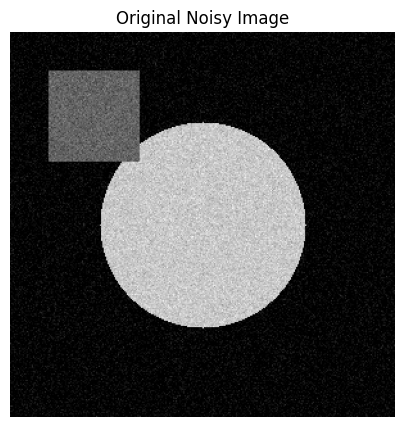

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Download a sample image if you don't have one
# We'll generate a synthetic gradient image with distinct regions for demonstration purposes.
width, height = 300, 300
image = np.zeros((height, width), dtype=np.uint8)
cv2.circle(image, (150, 150), 80, 200, -1)
cv2.rectangle(image, (30, 30), (100, 100), 100, -1)
# Add some noise
noise = np.random.normal(0, 15, image.shape).astype(np.int16)
image = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.title("Original Noisy Image")
plt.axis('off')
plt.show()

In [2]:
def calculate_otsu_fitness(thresholds, histogram, total_pixels):
    """Calculates Otsu's fitness (between-class variance) for a set of thresholds."""
    # Ensure thresholds are sorted and bounded within [0, 256]
    thresholds = sorted(list(thresholds))
    thresholds = [0] + thresholds + [256]

    variance = 0.0
    global_mean = np.sum(np.arange(256) * histogram) / total_pixels

    for i in range(len(thresholds) - 1):
        low, high = int(thresholds[i]), int(thresholds[i+1])
        weight = np.sum(histogram[low:high]) / total_pixels
        if weight == 0:
            continue
        mean = np.sum(np.arange(low, high) * histogram[low:high]) / (weight * total_pixels)
        variance += weight * (mean - global_mean) ** 2

    return variance

class Particle:
    def __init__(self, num_thresholds):
        self.position = np.sort(np.random.uniform(5, 250, num_thresholds))
        self.velocity = np.random.uniform(-10, 10, num_thresholds)
        self.best_position = np.copy(self.position)
        self.best_fitness = -1.0

def pso_segmentation(image, num_thresholds=2, num_particles=20, max_iter=50):
    # Calculate histogram
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).ravel()
    total_pixels = image.size

    # Initialize swarm
    particles = [Particle(num_thresholds) for _ in range(num_particles)]

    g_best_position = None
    g_best_fitness = -1.0

    w = 0.7  # Inertia weight
    c1 = 1.5 # Cognitive coefficient
    c2 = 1.5 # Social coefficient

    for iteration in range(max_iter):
        for particle in particles:
            # Evaluate fitness
            fitness = calculate_otsu_fitness(particle.position, hist, total_pixels)

            # Update personal best
            if fitness > particle.best_fitness:
                particle.best_fitness = fitness
                particle.best_position = np.copy(particle.position)

            # Update global best
            if fitness > g_best_fitness:
                g_best_fitness = fitness
                g_best_position = np.copy(particle.position)

        # Update velocities and positions
        for particle in particles:
            r1, r2 = np.random.rand(num_thresholds), np.random.rand(num_thresholds)
            cognitive = c1 * r1 * (particle.best_position - particle.position)
            social = c2 * r2 * (g_best_position - particle.position)
            particle.velocity = w * particle.velocity + cognitive + social

            # Apply velocity limits
            particle.velocity = np.clip(particle.velocity, -20, 20)

            # Update and constrain positions
            particle.position = np.clip(particle.position + particle.velocity, 1, 254)
            particle.position = np.sort(particle.position)

    return np.round(g_best_position).astype(int)

Optimal thresholds found by PSO: [ 54 150]


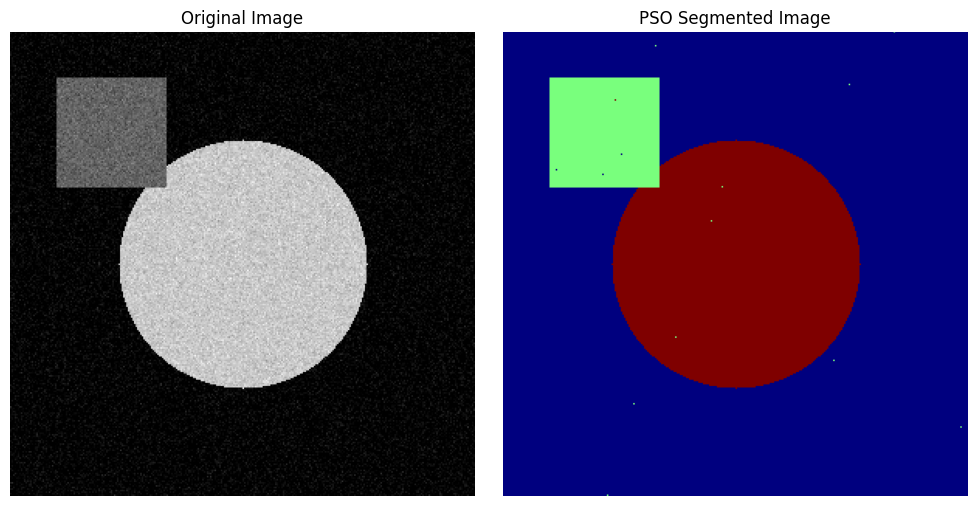

In [4]:
# Segment the image using PSO (finding 2 optimal thresholds -> 3 classes)
optimal_thresholds = pso_segmentation(image, num_thresholds=2)
print(f"Optimal thresholds found by PSO: {optimal_thresholds}")

# Apply the thresholds to segment the image
segmented_image = np.zeros_like(image)
thresholds = [0] + list(optimal_thresholds) + [256]

for i in range(len(thresholds) - 1):
    segmented_image[(image >= thresholds[i]) & (image < thresholds[i+1])] = int(255 / (len(thresholds) - 2) * i)

# Plot original vs segmented image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(segmented_image, cmap='jet')
axes[1].set_title("PSO Segmented Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()